# Financial Data Analysis Mini Project

This project analyzes multiple financial assets using Python to understand their performance, risk, and relationships.  

The objective is to explore how different asset classes behave over time and how diversification can help reduce overall investment risk while maintaining returns.

In [5]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    
    # flatten columns if multi-index
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    data.insert(0, 'Ticker', ticker)
    return data

In [ ]:
tickers = ['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU']
df_list = []

for t in tickers:
    temp = get_stock_data(t, start, end)
    
    temp = temp.reset_index()
    temp = temp.pivot(index='Date', columns='Ticker', values='Close')
    
    df_list.append(temp)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
stock = pd.concat(df_list, axis=1)
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888153,57.828777,72.245491,14.560221,114.166504,8.430121,29.219999
2020-01-03,294.640045,57.251514,71.592010,14.392557,115.924721,8.501048,29.620001
2020-01-06,295.764221,57.604698,71.856926,14.427855,115.266418,8.511180,29.920000
2020-01-07,294.932495,57.626614,71.636154,14.463151,114.699799,8.495981,30.040001
2020-01-08,296.504303,58.201443,71.927574,14.392557,113.941559,8.379459,29.820000


In [ ]:
print(stock.shape)
print(stock.columns)
print(stock.head())

(1584, 7)
Index(['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU'], dtype='str', name='Ticker')
Ticker             SPY        IYW         VT        DBA         TLT      PDBC  \
Date                                                                            
2020-01-02  296.888153  57.828777  72.245491  14.560221  114.166504  8.430121   
2020-01-03  294.640045  57.251514  71.592010  14.392557  115.924721  8.501048   
2020-01-06  295.764221  57.604698  71.856926  14.427855  115.266418  8.511180   
2020-01-07  294.932495  57.626614  71.636154  14.463151  114.699799  8.495981   
2020-01-08  296.504303  58.201443  71.927574  14.392557  113.941559  8.379459   

Ticker            IAU  
Date                   
2020-01-02  29.219999  
2020-01-03  29.620001  
2020-01-06  29.920000  
2020-01-07  30.040001  
2020-01-08  29.820000  


### Dataset Overview

The dataset contains historical closing prices of multiple financial assets, including stocks, bonds, and commodities.

Each column represents a different asset, while the index represents time (Date).

This structured dataset allows us to compare performance across different asset classes.

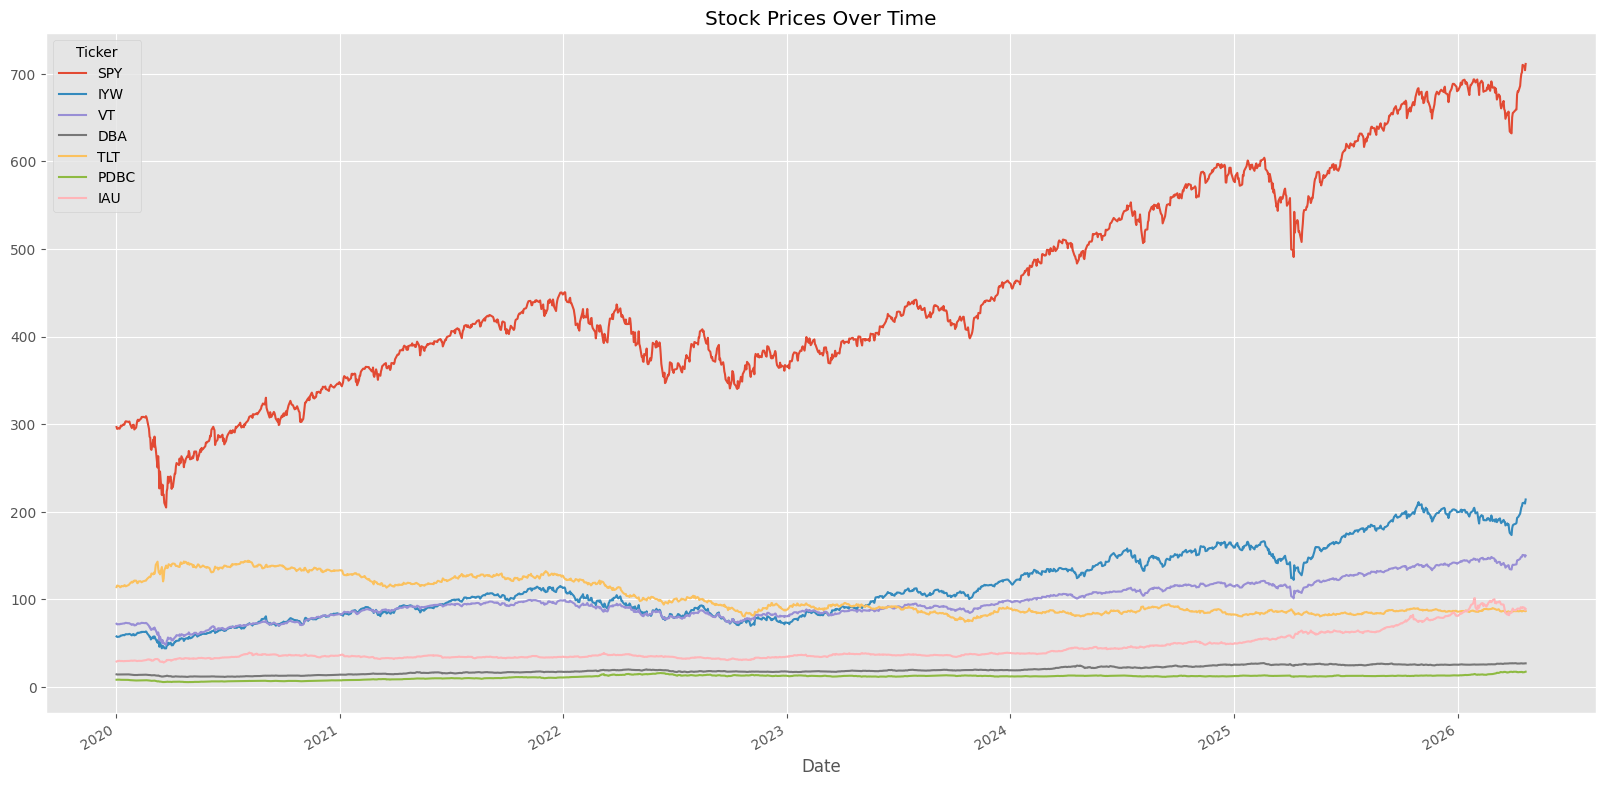

In [ ]:
plt.style.use('ggplot')
stock.plot(figsize=(20, 10), title="Stock Prices Over Time")
plt.show()

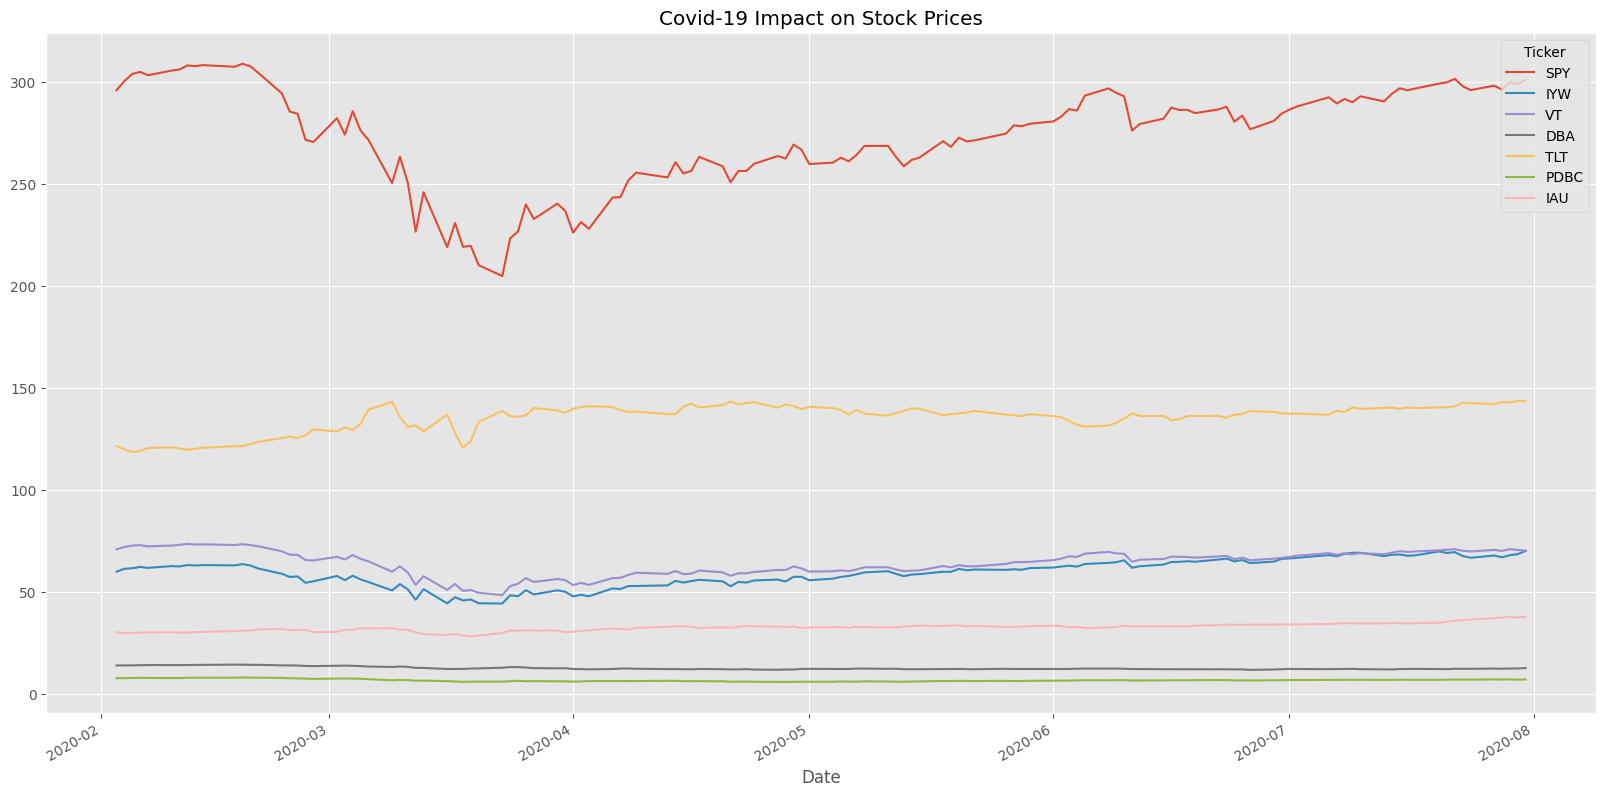

In [ ]:
covid = stock['2020-2-1':'2020-7-31']
plt.style.use('ggplot')
covid.plot(figsize=(20, 10), title="Covid-19 Impact on Stock Prices")
plt.show()

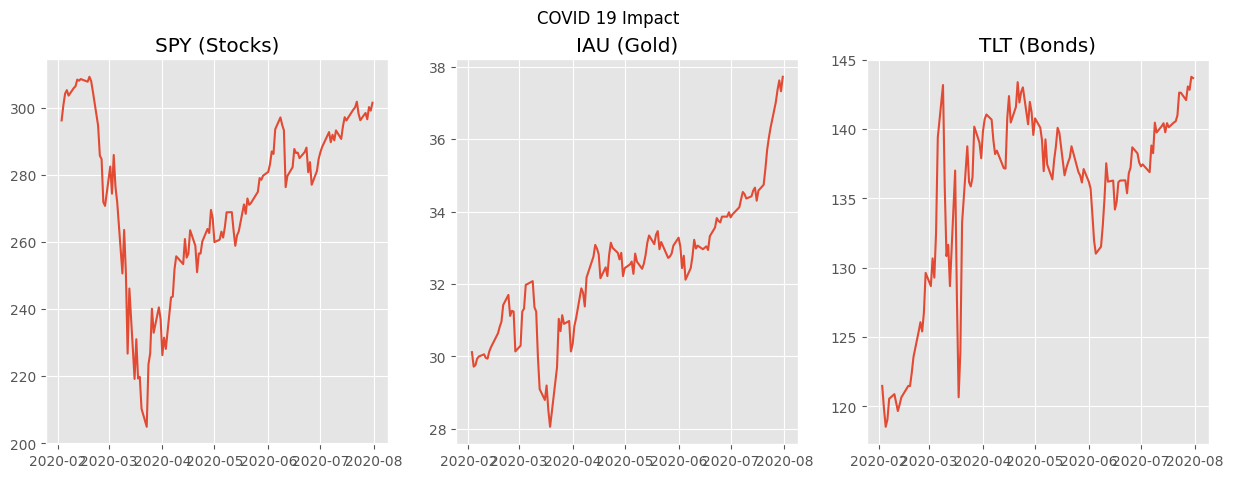

In [ ]:
x = covid.index
s_y = covid['SPY']
i_y = covid['IAU']
t_y = covid['TLT']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(x, s_y)
axs[0].set_title("SPY (Stocks)")

axs[1].plot(x, i_y)
axs[1].set_title("IAU (Gold)")

axs[2].plot(x, t_y)
axs[2].set_title("TLT (Bonds)")

fig.suptitle("COVID 19 Impact")
plt.show()

The visualization shows that most assets follow an upward trend over time.  
However, during early 2020, a sharp decline is observed due to the COVID-19 pandemic.

Different assets respond differently:
- Stocks experienced a sharp fall
- Gold remained relatively stable
- Bonds showed defensive behavior

This highlights the importance of diversification in financial markets.

[*********************100%***********************]  1 of 1 completed


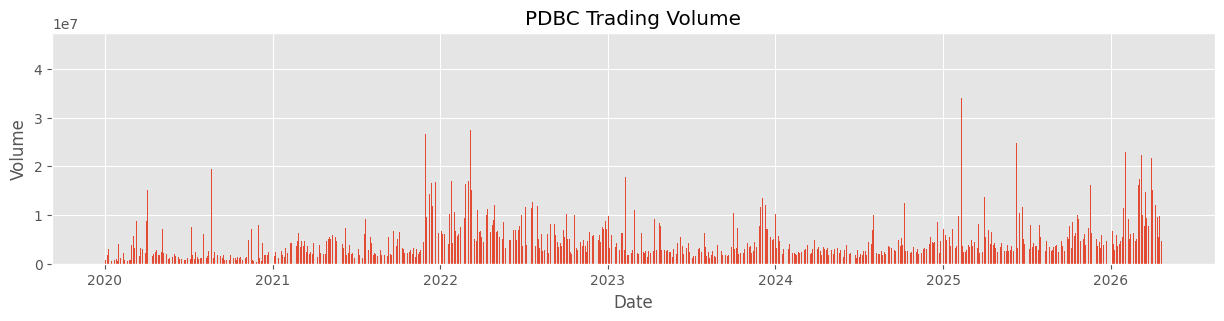

In [ ]:
ticker = 'PDBC'
start = datetime(2020,1,1)
end = datetime.today()

df = get_stock_data(ticker, start, end)
df.head()

df = df[['Volume']]

x = df.index
y = df['Volume']

plt.figure(figsize=(15, 3))
plt.bar(x, y)
plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

[*********************100%***********************]  1 of 1 completed


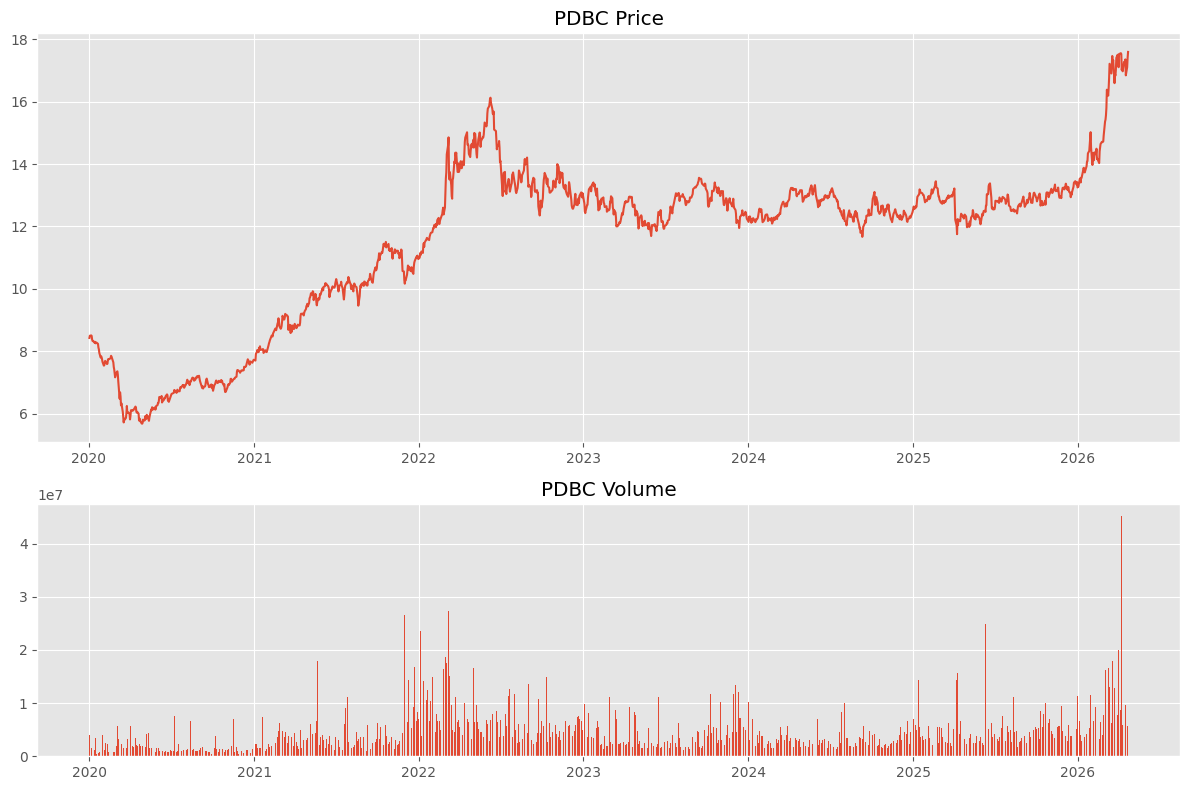

In [ ]:
ticker = 'PDBC'
df = get_stock_data(ticker, start, end)

fig = plt.figure(figsize=(12, 8))

# Price (top)
ax1 = plt.subplot2grid((5,1), (0,0), rowspan=3)
ax1.plot(df.index, df['Close'])
ax1.set_title(f"{ticker} Price")

# Volume (bottom)
ax2 = plt.subplot2grid((5,1), (3,0), rowspan=2)
ax2.bar(df.index, df['Volume'])
ax2.set_title(f"{ticker} Volume")

plt.tight_layout()
plt.show()

Observation

Trading volume shows significant spikes during certain periods, especially during market uncertainty.

Higher volume indicates increased market participation, often triggered by major events or news.

This suggests that investor activity increases during volatile periods.

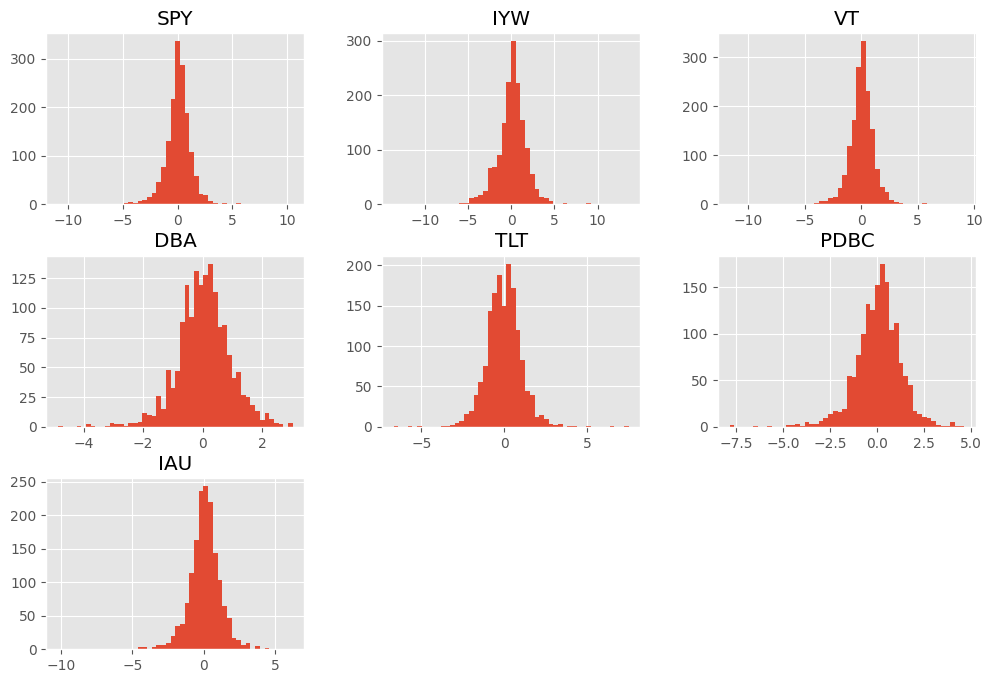

In [ ]:
returns = stock.pct_change() * 100
returns = returns.fillna(0)

returns.hist(bins=50, figsize=(12,8))
plt.show()

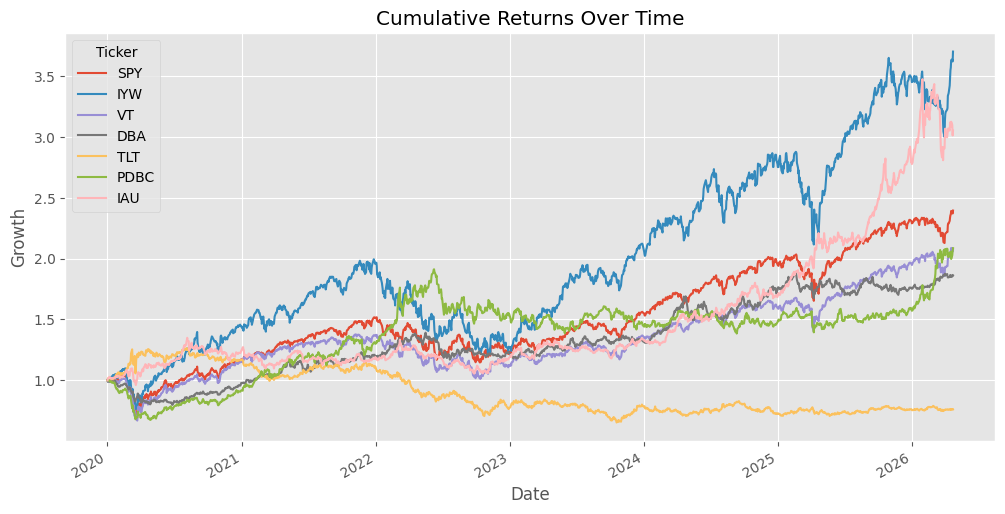

In [ ]:
cum_returns = (1 + returns/100).cumprod()
cum_returns.head()

cum_returns.plot(figsize=(12,6), title="Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.show()

Insight

Cumulative returns show how an investment grows over time.

Some assets demonstrate higher growth, while others remain stable.

This indicates a trade-off between risk and return, where higher returns are often associated with higher volatility.

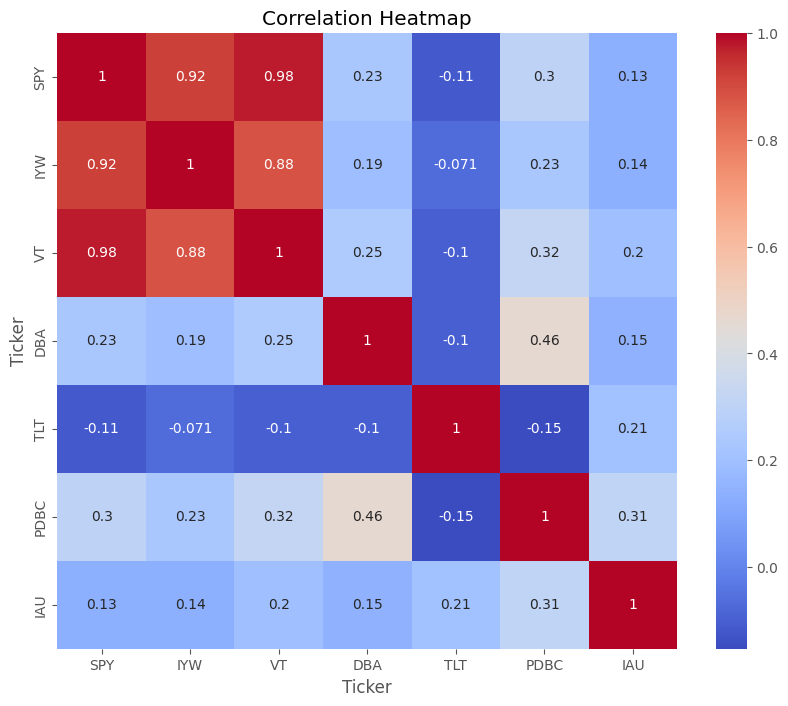

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = returns.corr()
corr

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationship between different assets.

- Stocks and technology ETFs show strong positive correlation
- Bonds have low or negative correlation with stocks
- Gold shows relatively low correlation with other assets

This confirms that combining assets with low correlation can reduce overall portfolio risk.

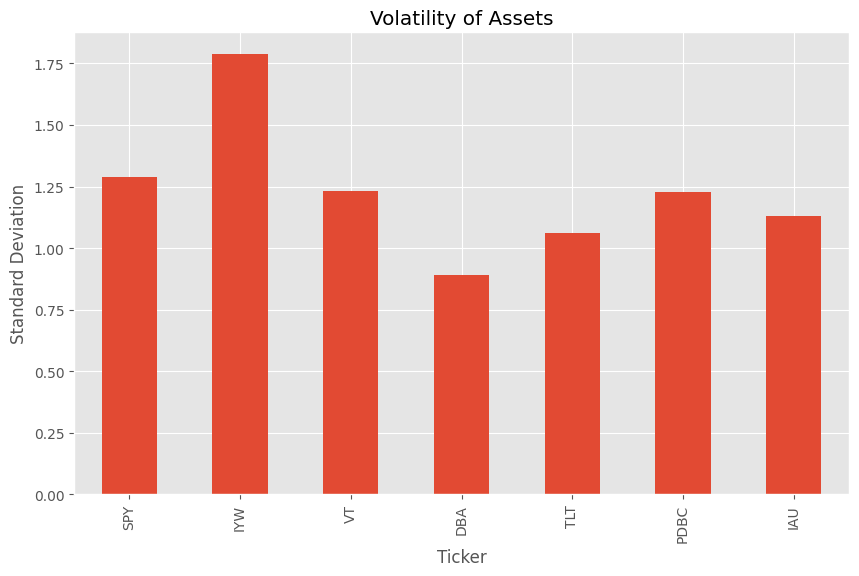

In [ ]:
volatility = returns.std()
volatility

volatility.plot(kind='bar', figsize=(10,6), title="Volatility of Assets")
plt.ylabel("Standard Deviation")
plt.show()

Insight

Volatility measures the risk associated with each asset.

Assets with higher volatility experience larger price fluctuations, indicating higher risk.

Safer assets such as bonds tend to have lower volatility, while growth-oriented assets such as technology stocks exhibit higher volatility.

# Conclusion

This project demonstrated how financial data can be analyzed to understand asset performance, risk, and relationships.

Key takeaways:
- Different assets behave differently under market conditions
- Diversification helps reduce overall risk
- Higher returns are often associated with higher volatility

Overall, this analysis highlights the importance of combining multiple asset classes to build a balanced and resilient investment portfolio.